# A Convolutional Neural Network (CNN) Image Classifier using CIFAR-10

### Goal: Classify images into 10 categories using a CNN

A CNN is designed for image data.

Instead of treating an image like a flat row of numbers, a CNN learns visual patterns step by step:

- Early layers learn edges and colors
- Middle layers learn shapes and textures
- Later layers learn object parts
- Final layer predicts the class



### Import Libraries

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix

### Make it reproducible

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


### Define image transformations

In [3]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

### Load the CIFAR-10 dataset

In [4]:
train_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

class_names = train_full.classes

print("Classes:", class_names)
print("Training images:", len(train_full))
print("Test images:", len(test_dataset))

100%|██████████| 170M/170M [00:01<00:00, 86.3MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training images: 50000
Test images: 10000


### Create training and validation sets

In [8]:
train_size = int(0.80 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

### Visualize sample images

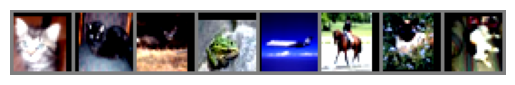

Labels:
['cat', 'cat', 'deer', 'frog', 'airplane', 'horse', 'cat', 'cat']


In [9]:
def imshow(img):
    img = img / 2 + 0.5
    np_img = img.numpy()
    plt.imshow(np.transpose(np_img, (1, 2, 0)))
    plt.axis("off")
    plt.show()


data_iter = iter(train_loader)
images, labels = next(data_iter)

imshow(torchvision.utils.make_grid(images[:8]))

print("Labels:")
print([class_names[label] for label in labels[:8]])